# Feature Importance Analysis - V62 Crypto Strategy

Notebook ini menganalisis **feature importance** dari model AI (XGBoost) yang digunakan dalam strategi V62.

**Tujuan:**
- Mengetahui fitur mana (`Vol_20`, `Mom_20`, `Mom_50`) yang paling dominan dalam keputusan AI
- Visualisasi berbagai bentuk grafik untuk pemahaman yang lebih baik
- Export hasil untuk dokumentasi thesis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('ggplot')
sns.set_palette("husl")

SEED = 42
np.random.seed(SEED)

print("✓ Libraries loaded!")

✓ Libraries loaded!


## 1. Load Data & Prepare Features

Menggunakan dataset yang sama dengan V62

In [2]:
# Load cryptocurrency data
file_path = '../experiment_nextLevel2/dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

print(f"Data: {len(data)} rows, {len(data.columns)} assets")
print(f"Period: {data.index[0]} to {data.index[-1]}")

Data: 990 rows, 25 assets
Period: 2023-04-17 00:00:00 to 2025-12-31 00:00:00


In [3]:
# Prepare features (sama seperti V62)
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

# Prepare target
sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

print("\n✓ Features created:")
print(features.head())


✓ Features created:
            Vol_20  Mom_20  Mom_50
Date                              
2023-04-30     NaN     NaN     NaN
2023-05-01     NaN     NaN     NaN
2023-05-02     NaN     NaN     NaN
2023-05-03     NaN     NaN     NaN
2023-05-04     NaN     NaN     NaN


## 2. Train XGBoost Model

Training periode: 2023-2024 (in-sample)

In [4]:
# Split training data (2023-2024)
X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]

print(f"Training samples: {len(X_train)}")
print(f"Positive class: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Negative class: {len(y_train) - y_train.sum()} ({(1-y_train.mean())*100:.1f}%)")

Training samples: 562
Positive class: 283.0 (50.4%)
Negative class: 279.0 (49.6%)


In [5]:
# Train XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=SEED,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Calculate optimized threshold
train_probs = xgb_model.predict_proba(X_train)[:, 1]
thresholds = np.linspace(0.3, 0.7, 41)
f_scores = [fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in thresholds]
opt_threshold = thresholds[np.argmax(f_scores)]

print(f"\n✓ Model trained successfully!")
print(f"Optimized Threshold: {opt_threshold:.2f}")
print(f"Best F0.5 Score: {max(f_scores):.4f}")


✓ Model trained successfully!
Optimized Threshold: 0.54
Best F0.5 Score: 0.8947


## 3. Extract Feature Importance

Mengambil feature importance dari model XGBoost

In [6]:
# Get feature importance
feature_importance = xgb_model.feature_importances_
feature_names = X_train.columns.tolist()

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance,
    'Importance_Pct': feature_importance / feature_importance.sum() * 100
}).sort_values('Importance', ascending=False)

print("\n=== FEATURE IMPORTANCE ===")
print(importance_df.to_string(index=False))
print(f"\nTotal Importance: {importance_df['Importance'].sum():.4f}")


=== FEATURE IMPORTANCE ===
Feature  Importance  Importance_Pct
 Mom_20    0.493168       49.316814
 Mom_50    0.256445       25.644514
 Vol_20    0.250387       25.038675

Total Importance: 1.0000


## 4. Visualisasi Feature Importance

### 4.1 Horizontal Bar Chart

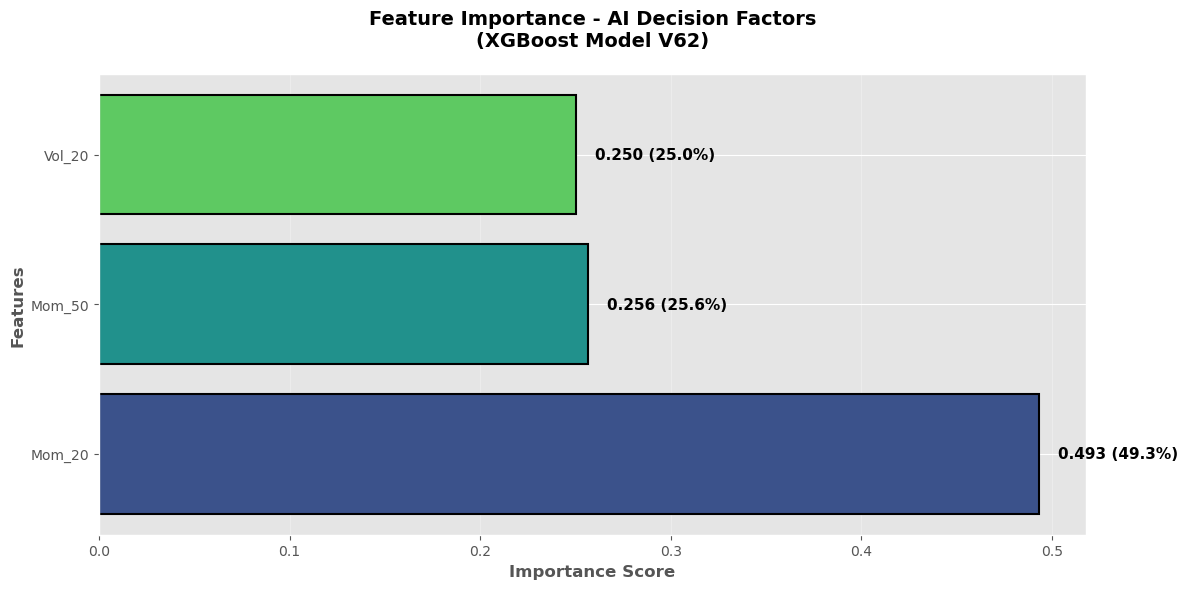

✓ Grafik horizontal disimpan!


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

# Create color palette
colors = sns.color_palette("viridis", len(importance_df))

# Create horizontal bars
bars = ax.barh(importance_df['Feature'], importance_df['Importance'], 
               color=colors, edgecolor='black', linewidth=1.5)

# Add value labels
for i, (idx, row) in enumerate(importance_df.iterrows()):
    ax.text(row['Importance'] + 0.01, i, 
            f"{row['Importance']:.3f} ({row['Importance_Pct']:.1f}%)",
            va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance - AI Decision Factors\n(XGBoost Model V62)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance_horizontal.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Grafik horizontal disimpan!")

### 4.2 Vertical Bar Chart dengan Persentase

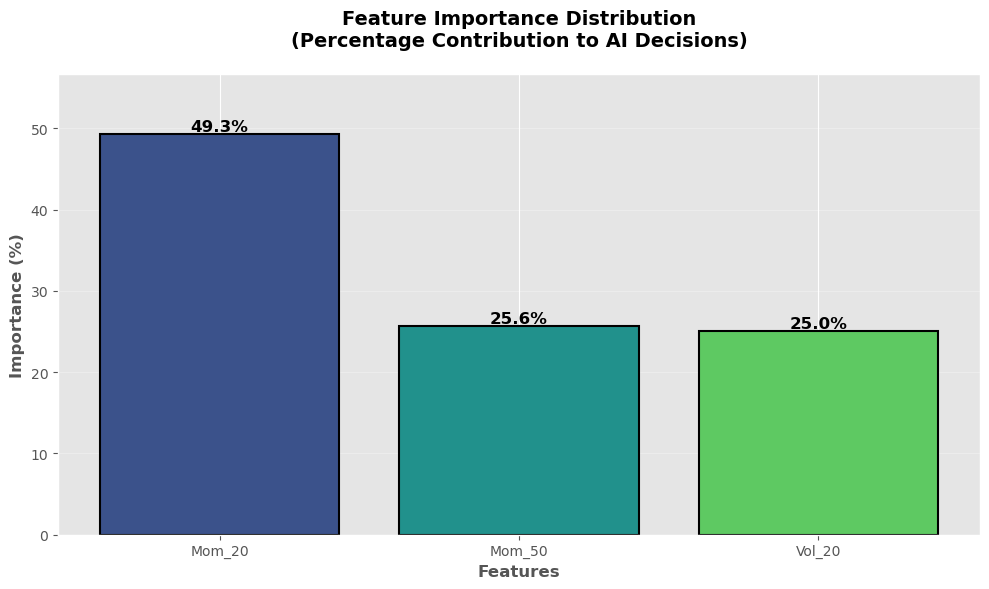

✓ Grafik vertikal disimpan!


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(importance_df['Feature'], importance_df['Importance_Pct'],
              color=colors, edgecolor='black', linewidth=1.5)

# Add percentage labels on top of bars
for bar, pct in zip(bars, importance_df['Importance_Pct']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{pct:.1f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Importance (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Features', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance Distribution\n(Percentage Contribution to AI Decisions)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, max(importance_df['Importance_Pct']) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance_vertical.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Grafik vertikal disimpan!")

### 4.3 Pie Chart - Proportional View

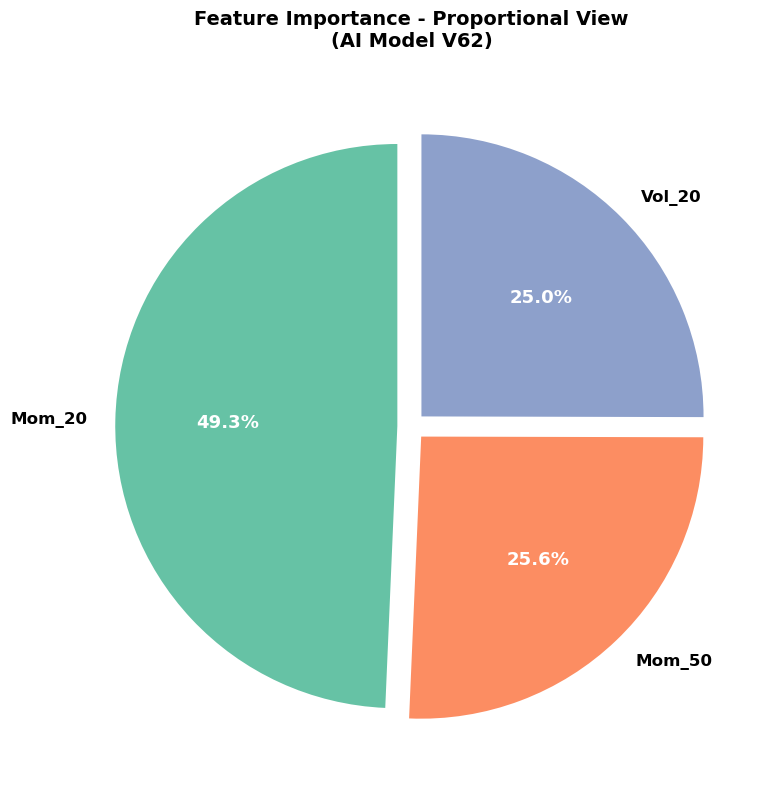

✓ Pie chart disimpan!


In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

colors_pie = sns.color_palette("Set2", len(importance_df))

wedges, texts, autotexts = ax.pie(
    importance_df['Importance'],
    labels=importance_df['Feature'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_pie,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    explode=[0.05] * len(importance_df)
)

# Make percentage text more visible
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')

ax.set_title('Feature Importance - Proportional View\n(AI Model V62)',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('feature_importance_pie.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Pie chart disimpan!")

## 5. Analisis Tambahan: Correlation dengan Target

In [10]:
# Calculate correlation with target
correlation_df = pd.DataFrame({
    'Feature': feature_names,
    'Correlation': [X_train[col].corr(y_train) for col in feature_names],
    'Abs_Correlation': [abs(X_train[col].corr(y_train)) for col in feature_names],
    'Importance': feature_importance,
    'Importance_Pct': importance_df['Importance_Pct'].values
}).sort_values('Importance', ascending=False)

print("\n=== FEATURE CORRELATION WITH TARGET ===")
print(correlation_df.to_string(index=False))


=== FEATURE CORRELATION WITH TARGET ===
Feature  Correlation  Abs_Correlation  Importance  Importance_Pct
 Mom_20    -0.359552         0.359552    0.493168       25.644514
 Mom_50    -0.230777         0.230777    0.256445       25.038675
 Vol_20    -0.012683         0.012683    0.250387       49.316814


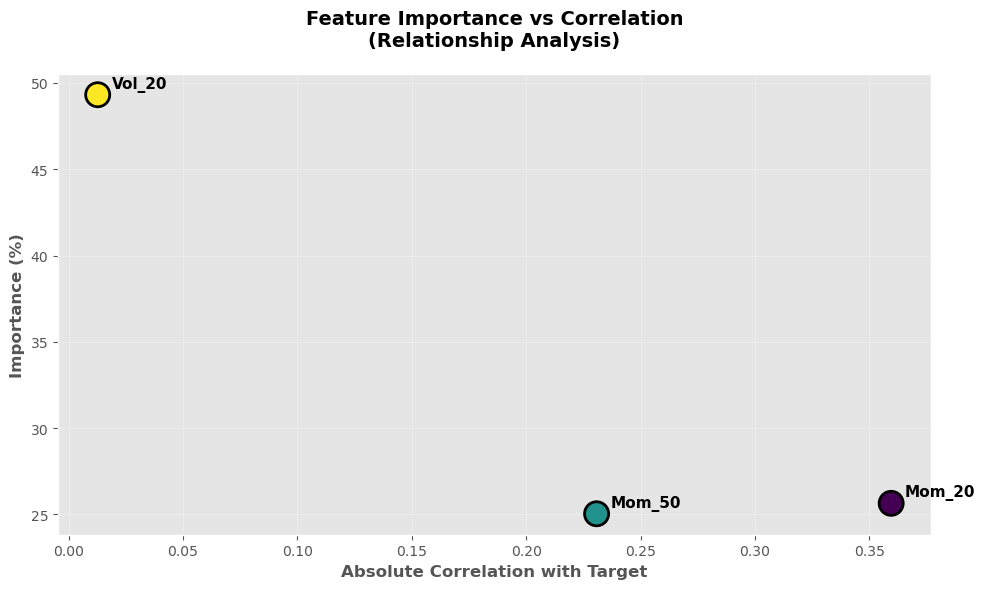

✓ Scatter plot disimpan!


In [11]:
# Visualisasi: Importance vs Correlation
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
scatter = ax.scatter(correlation_df['Abs_Correlation'], 
                     correlation_df['Importance_Pct'],
                     s=300, c=range(len(correlation_df)), 
                     cmap='viridis', edgecolors='black', linewidth=2)

# Add labels for each point
for idx, row in correlation_df.iterrows():
    ax.annotate(row['Feature'], 
                (row['Abs_Correlation'], row['Importance_Pct']),
                xytext=(10, 5), textcoords='offset points',
                fontsize=11, fontweight='bold')

ax.set_xlabel('Absolute Correlation with Target', fontsize=12, fontweight='bold')
ax.set_ylabel('Importance (%)', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance vs Correlation\n(Relationship Analysis)',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance_vs_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Scatter plot disimpan!")

## 6. Export Results to Excel

In [12]:
# Export to Excel
excel_filename = 'feature_importance_analysis_v62.xlsx'

with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    # Sheet 1: Feature Importance
    importance_df.to_excel(writer, sheet_name='Feature_Importance', index=False)
    
    # Sheet 2: Correlation Analysis
    correlation_df.to_excel(writer, sheet_name='Feature_Correlation', index=False)
    
    # Sheet 3: Model Info
    model_info = pd.DataFrame({
        'Parameter': ['Model Type', 'Training Period', 'Training Samples', 
                      'Optimized Threshold', 'Best F0.5 Score'],
        'Value': ['XGBoost Classifier', '2023-2024', len(X_train),
                  f'{opt_threshold:.2f}', f'{max(f_scores):.4f}']
    })
    model_info.to_excel(writer, sheet_name='Model_Info', index=False)

print(f"\n✓ Results exported to: {excel_filename}")


✓ Results exported to: feature_importance_analysis_v62.xlsx


## 7. Summary & Interpretation

### Key Findings:

In [13]:
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS - SUMMARY")
print("="*60)

# Find most important feature
most_important = importance_df.iloc[0]
print(f"\n📊 Most Dominant Feature:")
print(f"   → {most_important['Feature']}")
print(f"   → Importance: {most_important['Importance']:.4f} ({most_important['Importance_Pct']:.1f}%)")

print(f"\n📈 Ranking:")
for i, row in importance_df.iterrows():
    print(f"   {int(i)+1}. {row['Feature']:10s} : {row['Importance_Pct']:5.1f}%")

print(f"\n🔍 Interpretation:")
if most_important['Feature'] == 'Vol_20':
    print("   → Volatilitas (20-day) adalah faktor utama dalam keputusan AI")
    print("   → Model lebih sensitif terhadap risk/volatility daripada momentum")
elif most_important['Feature'] == 'Mom_50':
    print("   → Momentum jangka panjang (50-day) lebih dominan")
    print("   → Model fokus pada trend jangka panjang")
elif most_important['Feature'] == 'Mom_20':
    print("   → Momentum jangka pendek (20-day) lebih berpengaruh")
    print("   → Model responsif terhadap perubahan trend jangka pendek")

print("\n" + "="*60)
print("✓ Analysis completed successfully!")
print("="*60)

FEATURE IMPORTANCE ANALYSIS - SUMMARY

📊 Most Dominant Feature:
   → Mom_20
   → Importance: 0.4932 (49.3%)

📈 Ranking:
   2. Mom_20     :  49.3%
   3. Mom_50     :  25.6%
   1. Vol_20     :  25.0%

🔍 Interpretation:
   → Momentum jangka pendek (20-day) lebih berpengaruh
   → Model responsif terhadap perubahan trend jangka pendek

✓ Analysis completed successfully!


---

## 📁 Output Files Generated:

1. **feature_importance_horizontal.png** - Horizontal bar chart
2. **feature_importance_vertical.png** - Vertical bar chart dengan persentase  
3. **feature_importance_pie.png** - Pie chart proportional view
4. **feature_importance_vs_correlation.png** - Scatter plot comparison
5. **feature_importance_analysis_v62.xlsx** - Complete data export

---